# ASTRA-LM Experiment Analysis
Use this notebook to analyze and compare results from different experiment runs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import display

## Select Experiment Directory
Change the `run_path` to point to your experiment folder (e.g., `outputs/compare_gpt_vs_vayusphere/2026...`).

In [2]:
# Detect if running from the 'notebooks' directory or the project root
if os.path.basename(os.getcwd()) == "notebooks":
    run_path = os.path.join("..", "outputs", "compare_gpt_vs_vayusphere")
else:
    run_path = os.path.join("outputs", "compare_gpt_vs_vayusphere")

all_runs = sorted(glob.glob(os.path.join(run_path, "*")))
if all_runs:
    latest_run = all_runs[-1]
    print(f"Latest run found: {latest_run}")
    run_to_analyze = latest_run
else:
    print(f"No runs found in: {os.path.abspath(run_path)}")
    run_to_analyze = None

Latest run found: ..\outputs\compare_gpt_vs_vayusphere\20260621_212027_seed42_scratch_fair


## Load and Plot Metrics

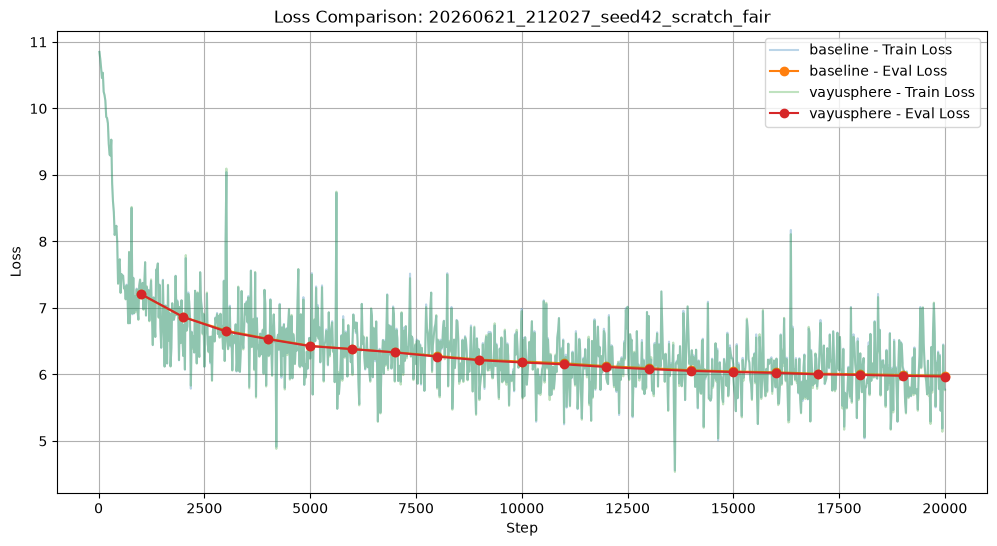

In [3]:
if run_to_analyze:
    subdirs = [d for d in os.listdir(run_to_analyze) if os.path.isdir(os.path.join(run_to_analyze, d))]
    
    plt.figure(figsize=(12, 6))
    
    for subdir in subdirs:
        metrics_file = os.path.join(run_to_analyze, subdir, "metrics.csv")
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            # Plot loss
            plt.plot(df['step'], df['loss'].interpolate(), label=f"{subdir} - Train Loss", alpha=0.3)
            
            # Plot eval loss
            eval_df = df.dropna(subset=['eval_loss'])
            if not eval_df.empty:
                plt.plot(eval_df['step'], eval_df['eval_loss'], marker='o', label=f"{subdir} - Eval Loss")
    
    plt.title(f"Loss Comparison: {os.path.basename(run_to_analyze)}")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## VayuSphere Diagnostics
If VayuSphere was active, we can check its gate and gradient statistics.


--- VayuSphere Diagnostics for vayusphere ---


,step,vs_q_gate_mean,vs_k_gate_mean,vs_centroid_grad_norm,vs_centroid_usage_entropy,vs_top_centroid_usage_ratio
1014,19920,0.063133,0.023683,0.002214,3.465378,0.140625
1015,19940,0.061679,0.029034,0.001720,3.465365,0.151428
1016,19960,0.068038,0.024683,0.002283,3.465418,0.137736
1017,19980,0.059022,0.027010,0.002081,3.465360,0.146281
1018,20000,0.058125,0.020169,0.002121,3.465355,0.147054


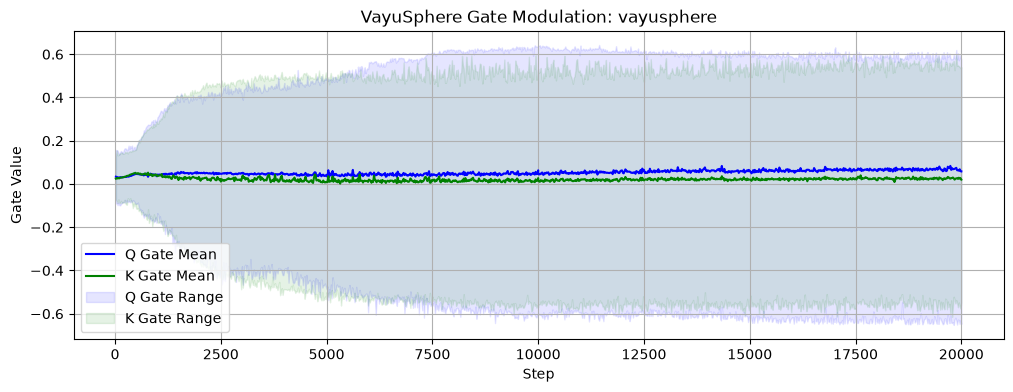

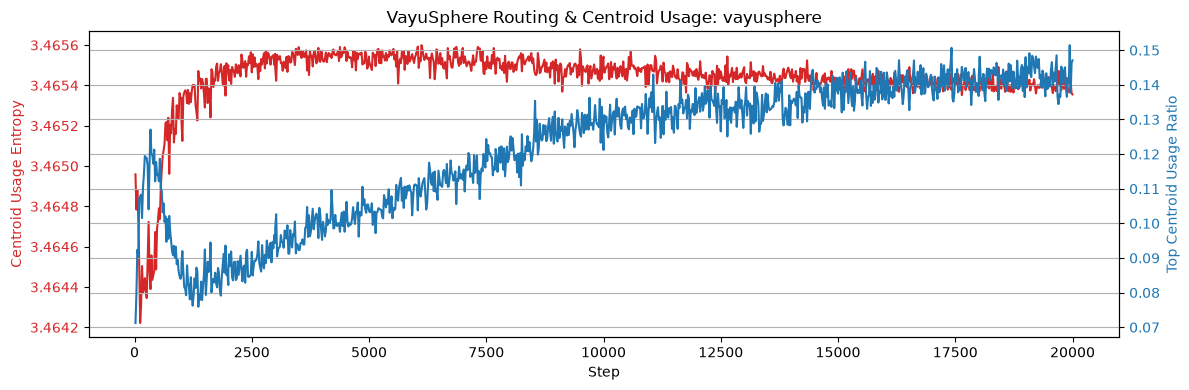

In [4]:
if run_to_analyze:
    for subdir in subdirs:
        metrics_file = os.path.join(run_to_analyze, subdir, "metrics.csv")
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            if 'vs_q_gate_mean' in df and not df['vs_q_gate_mean'].dropna().empty:
                print(f"\n--- VayuSphere Diagnostics for {subdir} ---")
                
                # Support both old and new column names
                grad_col = 'vs_centroid_grad_norm' if 'vs_centroid_grad_norm' in df else 'vs_centroid_grad_norm_mean'
                
                cols = ['step', 'vs_q_gate_mean', 'vs_k_gate_mean', grad_col]
                for extra_col in ['vs_centroid_usage_entropy', 'vs_top_centroid_usage_ratio']:
                    if extra_col in df:
                        cols.append(extra_col)
                        
                display(df[cols].dropna().tail())
                
                # Plot Gate Means
                plt.figure(figsize=(12, 4))
                plt.plot(df['step'], df['vs_q_gate_mean'].interpolate(), label='Q Gate Mean', color='blue')
                plt.plot(df['step'], df['vs_k_gate_mean'].interpolate(), label='K Gate Mean', color='green')
                
                # Plot Min/Max envelopes if available
                if 'vs_q_gate_min' in df and 'vs_q_gate_max' in df:
                    q_min_clean = df['vs_q_gate_min'].interpolate()
                    q_max_clean = df['vs_q_gate_max'].interpolate()
                    plt.fill_between(df['step'], q_min_clean, q_max_clean, alpha=0.1, color='blue', label='Q Gate Range')
                if 'vs_k_gate_min' in df and 'vs_k_gate_max' in df:
                    k_min_clean = df['vs_k_gate_min'].interpolate()
                    k_max_clean = df['vs_k_gate_max'].interpolate()
                    plt.fill_between(df['step'], k_min_clean, k_max_clean, alpha=0.1, color='green', label='K Gate Range')
                
                plt.title(f"VayuSphere Gate Modulation: {subdir}")
                plt.xlabel("Step")
                plt.ylabel("Gate Value")
                plt.legend()
                plt.grid(True)
                plt.show()
                
                # Plot Centroid Usage Diagnostics if available
                if 'vs_centroid_usage_entropy' in df or 'vs_top_centroid_usage_ratio' in df:
                    fig, ax1 = plt.subplots(figsize=(12, 4))
                    
                    color = 'tab:red'
                    ax1.set_xlabel('Step')
                    ax1.set_ylabel('Centroid Usage Entropy', color=color)
                    if 'vs_centroid_usage_entropy' in df:
                        ax1.plot(df['step'], df['vs_centroid_usage_entropy'].interpolate(), color=color, label='Entropy')
                    ax1.tick_params(axis='y', labelcolor=color)
                    
                    ax2 = ax1.twinx()
                    color = 'tab:blue'
                    ax2.set_ylabel('Top Centroid Usage Ratio', color=color)
                    if 'vs_top_centroid_usage_ratio' in df:
                        ax2.plot(df['step'], df['vs_top_centroid_usage_ratio'].interpolate(), color=color, label='Top Ratio')
                    ax2.tick_params(axis='y', labelcolor=color)
                    
                    plt.title(f"VayuSphere Routing & Centroid Usage: {subdir}")
                    fig.tight_layout()
                    plt.grid(True)
                    plt.show()